In [1]:
# Import required packages
import numpy as np
import matplotlib.pyplot as plt
from qsopt.core.experimental_parameters import (
    ExperimentalParameters,
    PhysicalConstants,
    SystemDimensions,
    MeasurementProtocol,
    InitialStateConfig,
    InteractionType,
    InitialStateType
)
from qsopt.core.trainable_parameters import TrainableParameters
from qsopt.core.experiment import SingleQubitExperiment, TwoQubitExperiment
from qsopt.utils import plot_sweep_results, plot_time_evolution

np.random.seed(42)

1. **Single Qubit**: Evolution over time and chi-gamma parameter sweep
2. **Two Uncoupled Qubits**: Final state probabilities P(00), P(01), P(10), P(11) vs chi-gamma
3. **Two Coupled Qubits**: Effects of qubit-qubit interaction on final state distributions

## Single Qubit


In [2]:
# Single Qubit Experiment Setup
phys_const_1q = PhysicalConstants(
    n_qubits=1,
    chi=[5.0],  # Dispersive coupling
    photon_cavity_coupling=10.0,  # gamma
    inverse_pulse_width=1.0  # sigma (pulse width parameter)
)

sys_dims_1q = SystemDimensions(
    field_levels=2,
    cavity_levels=2,
    qubit_levels=[2]
)

meas_protocol_1q = MeasurementProtocol(
    measurement_times=[-5., 5.],
    initial_time_uncertainty=0.0
)

initial_state_1q = InitialStateConfig(state_type=InitialStateType.SINGLE_PHOTON)

exp_params_1q = ExperimentalParameters(
    physical_constants=phys_const_1q,
    system_dims=sys_dims_1q,
    measurement=meas_protocol_1q,
    initial_state=initial_state_1q
)

train_params_1q = TrainableParameters()
train_params_1q.add_rotation_angles(['ry1', 'ry2'], [np.pi/2, -np.pi/2])

# Create experiment
exp_1q = SingleQubitExperiment(exp_params_1q, train_params_1q)

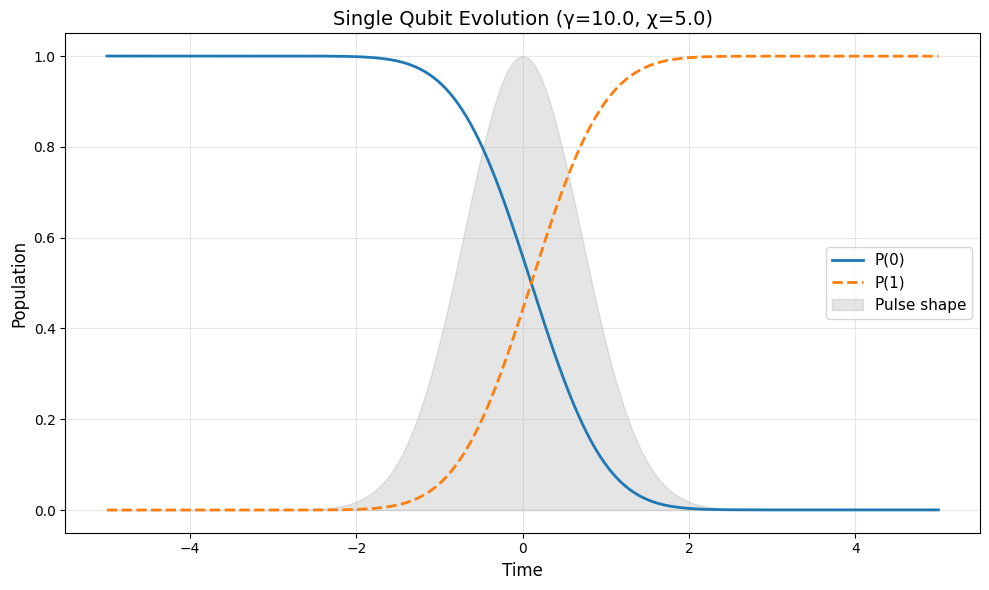

In [29]:
# Single Qubit: Time evolution

results_1q_time = exp_1q.time_evolution(t_start=-5.0, t_end=5.0, n_points=200, with_interaction=True)

# Use unified plot_time_evolution with evolution_data dict
plot_time_evolution(
    evolution_data=results_1q_time,
    show_pulse=True,
    show_measurements=True,
    title=f'Single Qubit Evolution (γ={phys_const_1q.photon_cavity_coupling}, χ={phys_const_1q.chi[0]})',
    figsize=(10, 6)
)
plt.show()

Now we sweep over chi and gamma parameters to find the optimal sensing configuration.
This reproduces the contour plot from the reference notebook.

In [6]:
results_1q_sweep = exp_1q.sweep_chi_gamma(
    chi_interval=[0.1, 15.0],
    gamma_interval=[0.1, 30.0],
    resolution_chi=10,
    resolution_gamma=10,
    chi_scale='linear',
    gamma_scale='linear',
    batch_size=1,
    verbose=True
)

Computing χ-γ parameter sweep...
  Resolution: 10×10 = 100 points
  χ range: [0.10, 15.00] (linear scale)
  γ range: [0.10, 30.00] (linear scale)
  Progress: 10.0% | Elapsed: 9.5s
  Progress: 10.0% | Elapsed: 9.5s
  Progress: 20.0% | Elapsed: 18.8s
  Progress: 20.0% | Elapsed: 18.8s
  Progress: 30.0% | Elapsed: 28.5s
  Progress: 30.0% | Elapsed: 28.5s
  Progress: 40.0% | Elapsed: 38.3s
  Progress: 40.0% | Elapsed: 38.3s
  Progress: 50.0% | Elapsed: 48.4s
  Progress: 50.0% | Elapsed: 48.4s
  Progress: 60.0% | Elapsed: 58.1s
  Progress: 60.0% | Elapsed: 58.1s
  Progress: 70.0% | Elapsed: 68.0s
  Progress: 70.0% | Elapsed: 68.0s
  Progress: 80.0% | Elapsed: 77.3s
  Progress: 80.0% | Elapsed: 77.3s
  Progress: 90.0% | Elapsed: 87.3s
  Progress: 90.0% | Elapsed: 87.3s
  Progress: 100.0% | Elapsed: 97.4s
✓ Sweep completed in 97.4s
  Max contrast: 0.999996
  Optimal χ: 15.000
  Optimal γ: 30.000
  Progress: 100.0% | Elapsed: 97.4s
✓ Sweep completed in 97.4s
  Max contrast: 0.999996
  Optimal 

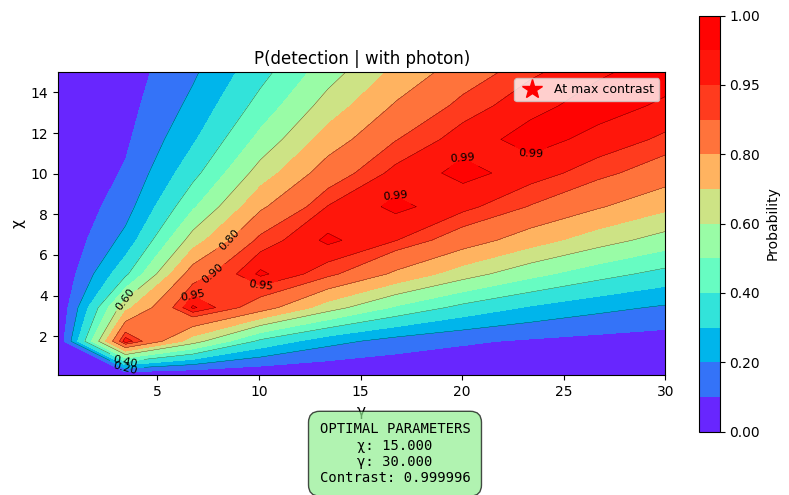

In [39]:
plot_sweep_results(
    results_1q_sweep,
    results_to_plot=['detection_map'],
    figsize=(8, 5)
)
plt.show()

## Two Qubits

Now we move to two-qubit experiments.
We'll plot all four final state probabilities: P(00), P(01), P(10), P(11).

In [20]:
phys_const_2q = PhysicalConstants(
    n_qubits=2,
    chi=[40.0, 40.0],  # Equal dispersive coupling for both qubits
    photon_cavity_coupling=10.0,  # gamma
    inverse_pulse_width=1.0,
    qubit_interactions=[]  # No qubit-qubit coupling (chi12=0)
)

sys_dims_2q = SystemDimensions(
    field_levels=2,
    cavity_levels=2,
    qubit_levels=[2, 2]
)

meas_protocol_2q = MeasurementProtocol(
    measurement_times=[-5, 5],
)

initial_state_2q = InitialStateConfig(
    state_type=InitialStateType.SINGLE_PHOTON
)

exp_params_2q = ExperimentalParameters(
    physical_constants=phys_const_2q,
    system_dims=sys_dims_2q,
    measurement=meas_protocol_2q,
    initial_state=initial_state_2q
)

# Rotation parameters for both qubits (theta1_q1, theta2_q1, theta1_q2, theta2_q2)
train_params_2q = TrainableParameters()
train_params_2q.add_rotation_angles(
    ["theta1_q1", "theta2_q1", "theta1_q2", "theta2_q2"],
    [np.pi/2, -np.pi/2, np.pi/2, -np.pi/2]
)

# Create experiment with default detector (1-P(00))
exp_2q_uncoupled = TwoQubitExperiment(exp_params_2q, train_params_2q)

{'times': array([-5.        , -4.94974874, -4.89949749, -4.84924623, -4.79899497,
       -4.74874372, -4.69849246, -4.64824121, -4.59798995, -4.54773869,
       -4.49748744, -4.44723618, -4.39698492, -4.34673367, -4.29648241,
       -4.24623116, -4.1959799 , -4.14572864, -4.09547739, -4.04522613,
       -3.99497487, -3.94472362, -3.89447236, -3.84422111, -3.79396985,
       -3.74371859, -3.69346734, -3.64321608, -3.59296482, -3.54271357,
       -3.49246231, -3.44221106, -3.3919598 , -3.34170854, -3.29145729,
       -3.24120603, -3.19095477, -3.14070352, -3.09045226, -3.04020101,
       -2.98994975, -2.93969849, -2.88944724, -2.83919598, -2.78894472,
       -2.73869347, -2.68844221, -2.63819095, -2.5879397 , -2.53768844,
       -2.48743719, -2.43718593, -2.38693467, -2.33668342, -2.28643216,
       -2.2361809 , -2.18592965, -2.13567839, -2.08542714, -2.03517588,
       -1.98492462, -1.93467337, -1.88442211, -1.83417085, -1.7839196 ,
       -1.73366834, -1.68341709, -1.63316583, -1.58291

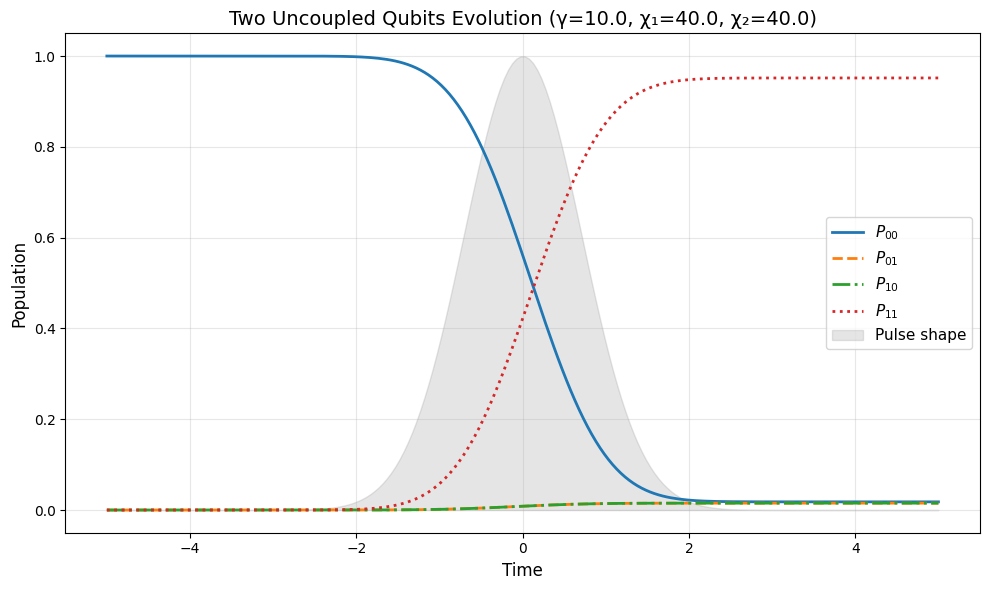

In [ ]:
# Two Uncoupled Qubits: Time evolution
results_2q_time = exp_2q_uncoupled.time_evolution(t_start=-5.0, t_end=5.0, n_points=200)

plot_time_evolution(
    evolution_data=results_2q_time,
    show_pulse=True,
    show_measurements=True,
    title=f'Two Uncoupled Qubits Evolution (γ={phys_const_2q.photon_cavity_coupling}, χ₁={phys_const_2q.chi[0]}, χ₂={phys_const_2q.chi[1]})',
    figsize=(10, 6),
    save_path='two_uncoupled_qubits_evolution.png'
)
plt.show()


We now sweep over chi and gamma to see all four probability maps.

In [24]:
results_2q_sweep = exp_2q_uncoupled.sweep_chi_gamma(
    chi_interval=[0.1, 40.0],
    gamma_interval=[0.1, 40.0],
    resolution_chi=40,
    resolution_gamma=40,
    chi_scale='linear',
    gamma_scale='linear',
    batch_size=1,
    verbose=True
)

Computing χ-γ parameter sweep...
  Resolution: 40×40 = 1600 points
  χ range: [0.10, 40.00] (linear scale)
  γ range: [0.10, 40.00] (linear scale)
  Progress: 10.0% | Elapsed: 251.6s
  Progress: 10.0% | Elapsed: 251.6s
  Progress: 20.0% | Elapsed: 507.9s
  Progress: 20.0% | Elapsed: 507.9s
  Progress: 30.0% | Elapsed: 776.8s
  Progress: 30.0% | Elapsed: 776.8s
  Progress: 40.0% | Elapsed: 1049.0s
  Progress: 40.0% | Elapsed: 1049.0s
  Progress: 50.0% | Elapsed: 1336.1s
  Progress: 50.0% | Elapsed: 1336.1s
  Progress: 60.0% | Elapsed: 1646.1s
  Progress: 60.0% | Elapsed: 1646.1s
  Progress: 70.0% | Elapsed: 1949.3s
  Progress: 70.0% | Elapsed: 1949.3s
  Progress: 80.0% | Elapsed: 2266.6s
  Progress: 80.0% | Elapsed: 2266.6s
  Progress: 90.0% | Elapsed: 2603.5s
  Progress: 90.0% | Elapsed: 2603.5s
  Progress: 100.0% | Elapsed: 2947.2s
✓ Sweep completed in 2947.2s
  Max contrast: 0.992773
  Optimal χ: 40.000
  Optimal γ: 18.515
  Progress: 100.0% | Elapsed: 2947.2s
✓ Sweep completed in 29

Sweep results plot saved to: two_uncoupled_qubits_probability_maps.png


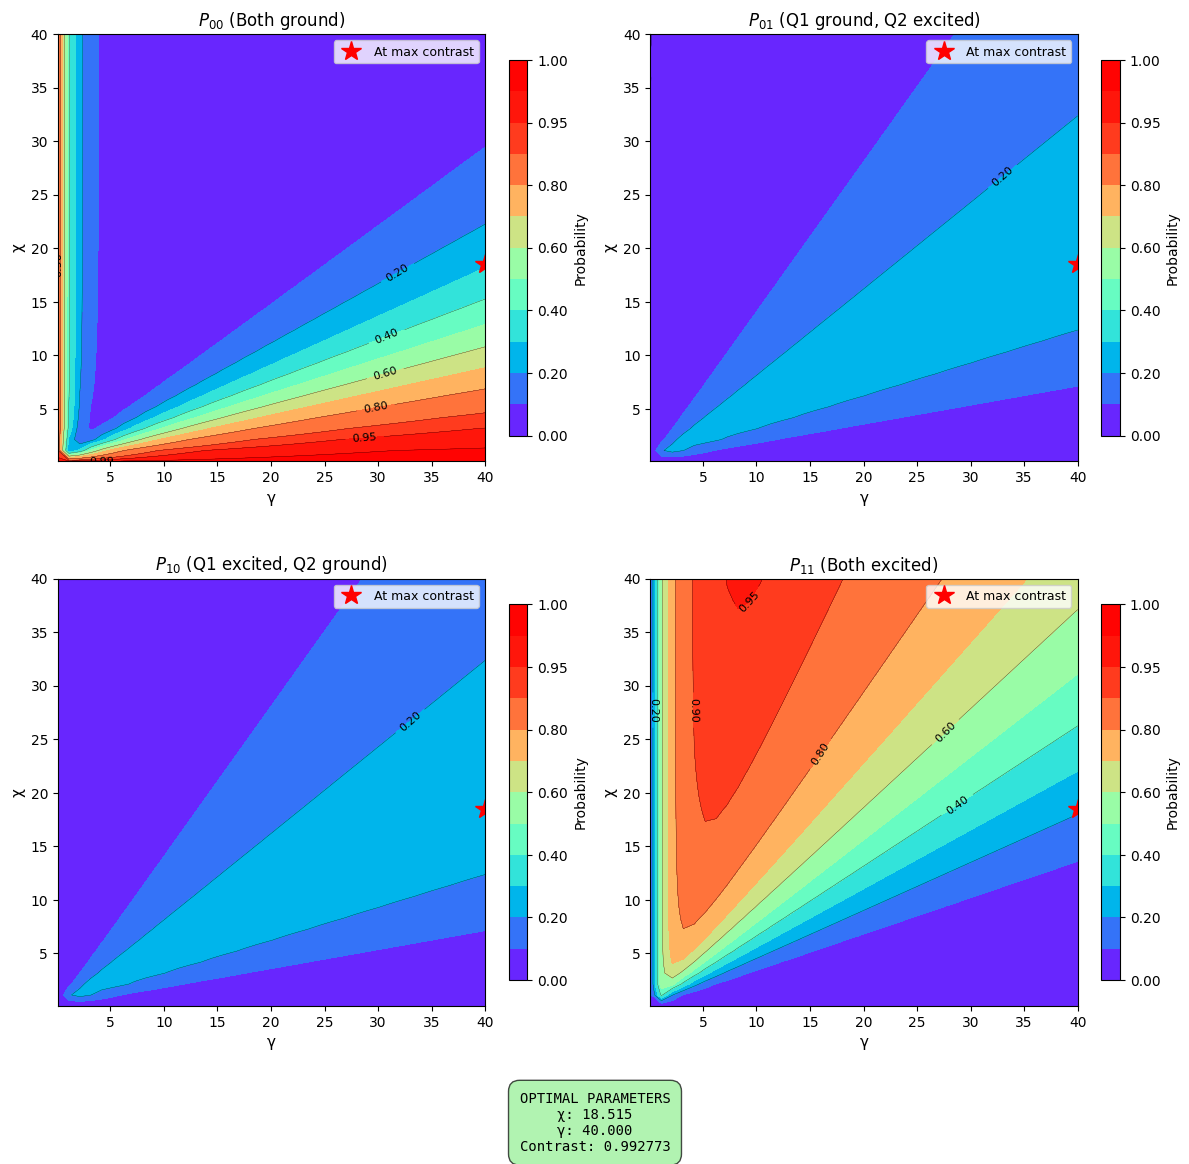

In [28]:
# Use unified plot_sweep_results to plot all four probability maps in 2x2 grid
plot_sweep_results(
    results_2q_sweep,
    results_to_plot=['p00', 'p01', 'p10', 'p11'],
    figsize=(12, 12),
    save_path='two_uncoupled_qubits_probability_maps.png'
)
plt.show()

Sweep results plot saved to: two_uncoupled_qubits_contrast_detection_maps.png


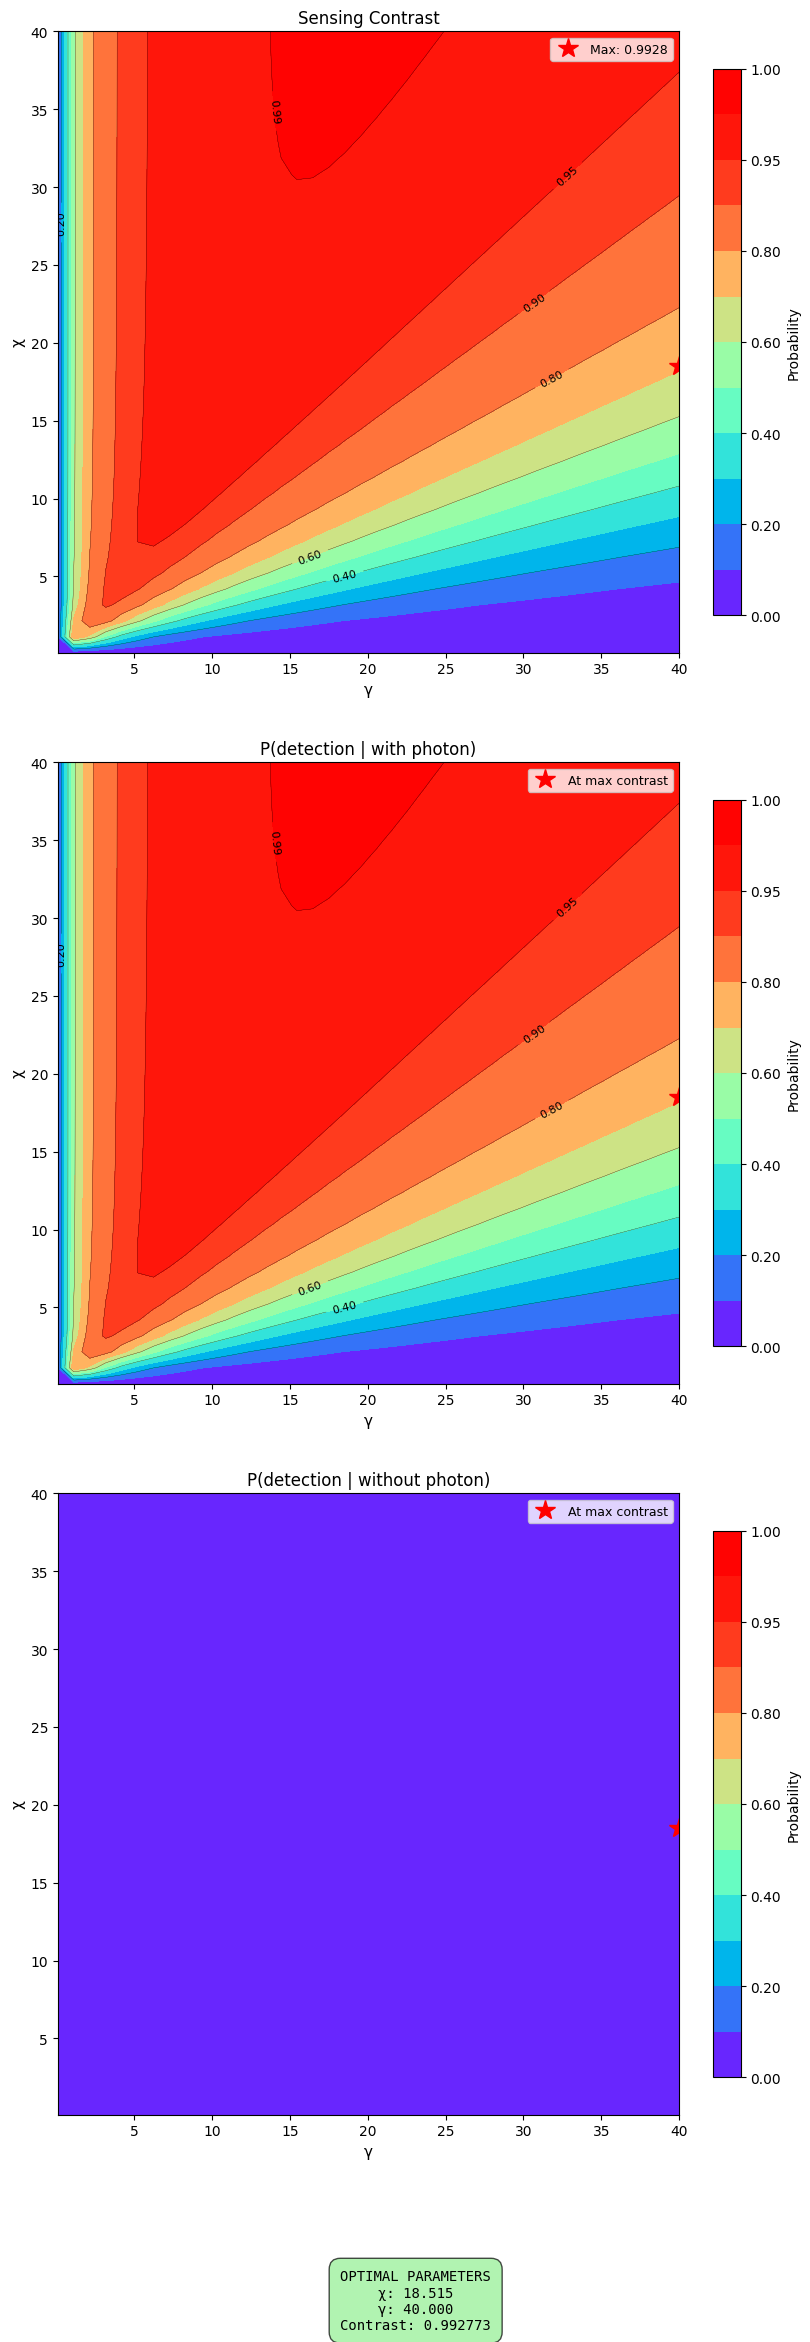

In [41]:
# Plot contrast map and detection maps with optimal point marked
plot_sweep_results(
    results_2q_sweep,
    results_to_plot=['contrast_map', 'detection_map', 'detection_without_map'],
    mark_optimal=True,
    save_path='two_uncoupled_qubits_contrast_detection_maps.png'
)
plt.show()

## Asymmetry Sweeps

In [32]:
# Import the asymmetry sweep functions
from qsopt.utils import compute_asymmetry_coupling_sweep, compute_asymmetry_gamma_sweep

# Asymmetry-Coupling Sweep: Δχ/γ vs χ₁₂/γ
# We fix γ=10 and vary the asymmetry and qubit-qubit coupling
results_asymmetry_coupling = compute_asymmetry_coupling_sweep(
    exp_2q_uncoupled,
    asymmetry_interval=[-8.0, 8.0],
    coupling_interval=[0.0, 10.0],
    resolution_asymmetry=30,
    resolution_coupling=30,
    chi_mean_factor=10.0,  # χ_mean = 10 * γ = 100
    gamma=10.0,
    verbose=True
)

Computing asymmetry-coupling parameter sweep...
  Resolution: 30×30 = 900 points
  Δχ/γ range: [-8.00, 8.00]
  χ₁₂/γ range: [0.00, 10.00]
  χ_mean/γ = 10.0, γ = 10.0
  Progress: 10.0% | Elapsed: 227.4s
  Progress: 10.0% | Elapsed: 227.4s
  Progress: 20.0% | Elapsed: 480.0s
  Progress: 20.0% | Elapsed: 480.0s
  Progress: 30.0% | Elapsed: 715.5s
  Progress: 30.0% | Elapsed: 715.5s
  Progress: 40.0% | Elapsed: 972.9s
  Progress: 40.0% | Elapsed: 972.9s
  Progress: 50.0% | Elapsed: 1233.1s
  Progress: 50.0% | Elapsed: 1233.1s
  Progress: 60.0% | Elapsed: 1472.6s
  Progress: 60.0% | Elapsed: 1472.6s
  Progress: 70.0% | Elapsed: 1741.2s
  Progress: 70.0% | Elapsed: 1741.2s
  Progress: 80.0% | Elapsed: 1980.1s
  Progress: 80.0% | Elapsed: 1980.1s
  Progress: 90.0% | Elapsed: 2216.2s
  Progress: 90.0% | Elapsed: 2216.2s
  Progress: 100.0% | Elapsed: 2482.8s
✓ Sweep completed in 2482.8s
  Max contrast: 0.981366
  Optimal Δχ/γ: -0.276
  Optimal χ₁₂/γ: 0.000
  Progress: 100.0% | Elapsed: 2482.8s


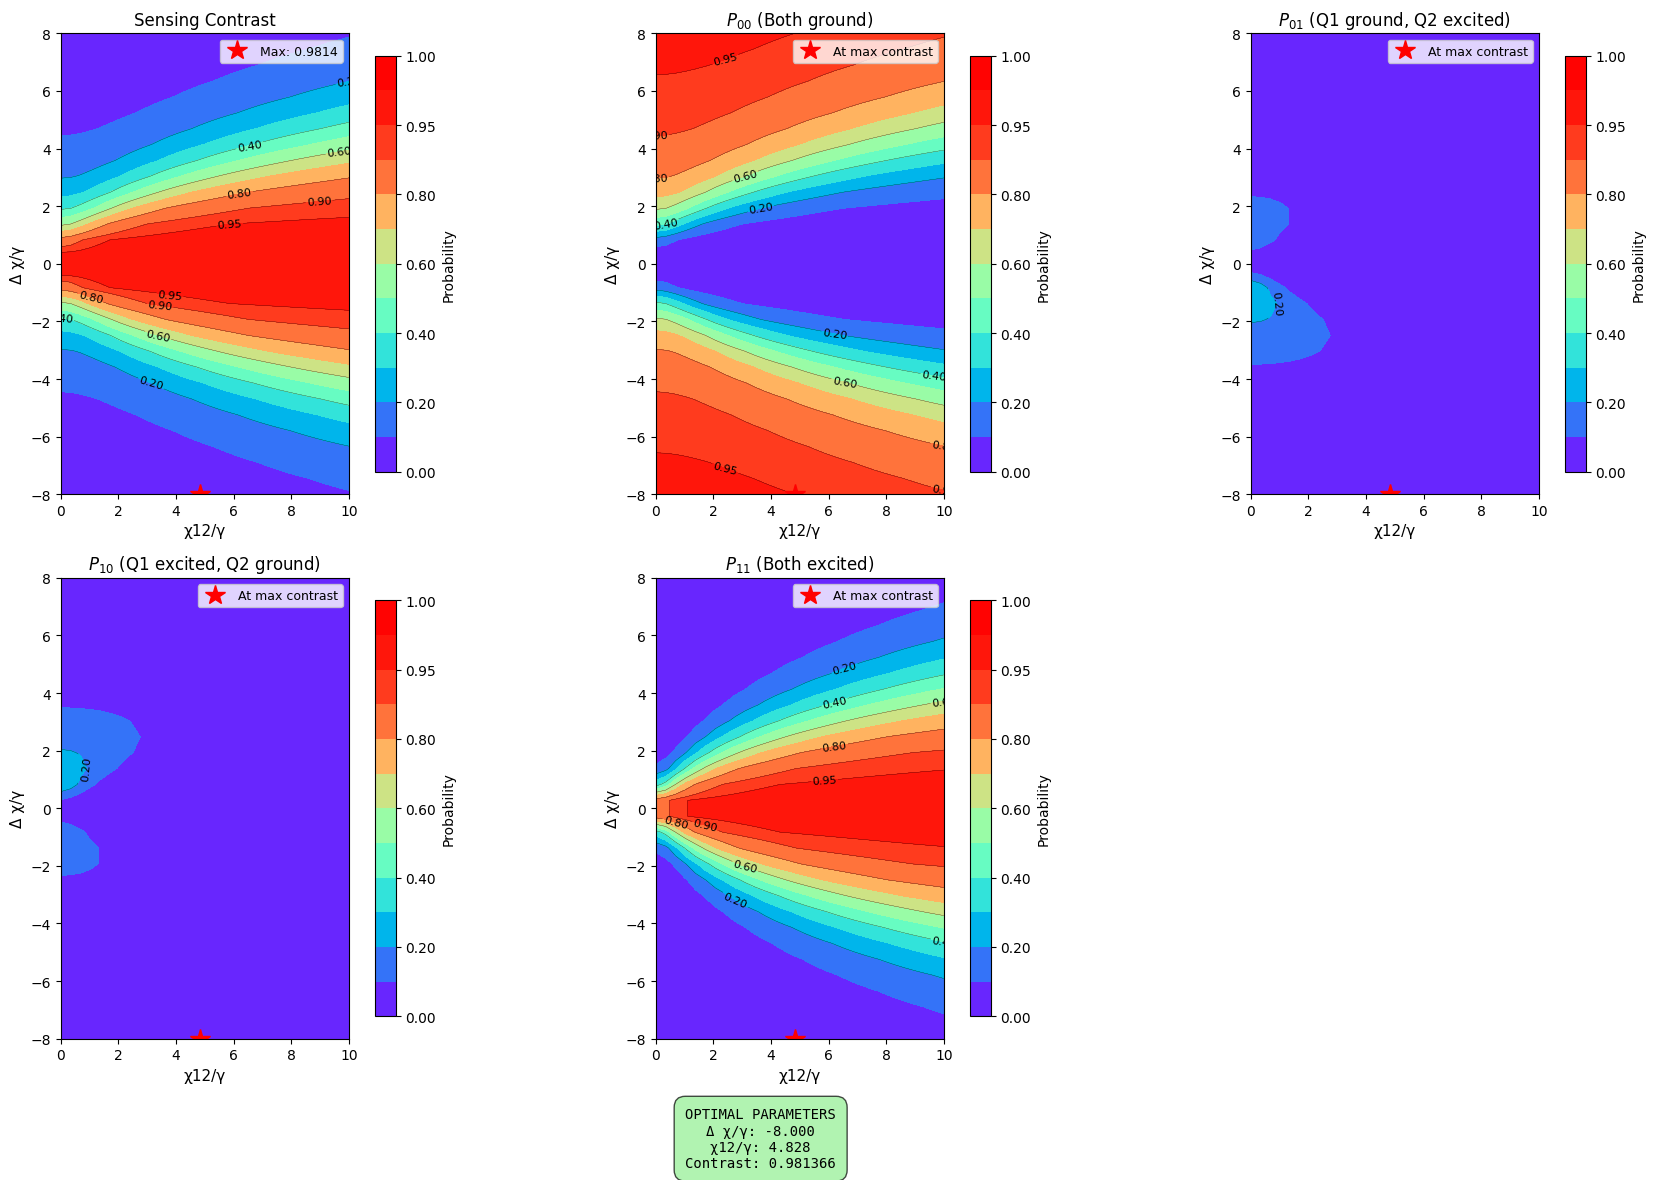

In [ ]:
# Plot asymmetry-coupling sweep results
# Show contrast map and all four probabilities
plot_sweep_results(
    results_asymmetry_coupling,
    results_to_plot=['contrast_map', 'p00', 'p01', 'p10', 'p11', 'detection_map', 'detection_without_map'],
    mark_optimal=True
)
plt.show()

In [34]:
# Asymmetry-Gamma Sweep: Δχ/γ vs γ
# Now we vary both asymmetry and gamma itself
results_asymmetry_gamma = compute_asymmetry_gamma_sweep(
    exp_2q_uncoupled,
    asymmetry_interval=[-8.0, 8.0],
    gamma_interval=[0.1, 20.0],
    resolution_asymmetry=30,
    resolution_gamma=30,
    chi_mean_factor=10.0,  # χ_mean = 10 * γ (scales with gamma)
    chi12_factor=5.0,       # χ₁₂ = 5 * γ (scales with gamma)
    verbose=True
)

Computing asymmetry-gamma parameter sweep...
  Resolution: 30×30
  Δχ/γ range: [-8.00, 8.00]
  γ range: [0.10, 20.00]
  χ_mean/γ = 10.0, χ₁₂/γ = 5.0
  Progress: 10.0% | Elapsed: 237.9s
  Progress: 10.0% | Elapsed: 237.9s
  Progress: 20.0% | Elapsed: 478.3s
  Progress: 20.0% | Elapsed: 478.3s
  Progress: 30.0% | Elapsed: 754.1s
  Progress: 30.0% | Elapsed: 754.1s
  Progress: 40.0% | Elapsed: 997.3s
  Progress: 40.0% | Elapsed: 997.3s
  Progress: 50.0% | Elapsed: 1239.4s
  Progress: 50.0% | Elapsed: 1239.4s
  Progress: 60.0% | Elapsed: 1484.0s
  Progress: 60.0% | Elapsed: 1484.0s
  Progress: 70.0% | Elapsed: 1768.5s
  Progress: 70.0% | Elapsed: 1768.5s
  Progress: 80.0% | Elapsed: 2015.9s
  Progress: 80.0% | Elapsed: 2015.9s
  Progress: 90.0% | Elapsed: 2264.0s
  Progress: 90.0% | Elapsed: 2264.0s
  Progress: 100.0% | Elapsed: 2514.7s
✓ Sweep completed in 2514.7s
  Max contrast: 0.994088
  Optimal Δχ/γ: 0.276
  Optimal γ: 20.000
  Progress: 100.0% | Elapsed: 2514.7s
✓ Sweep completed in 

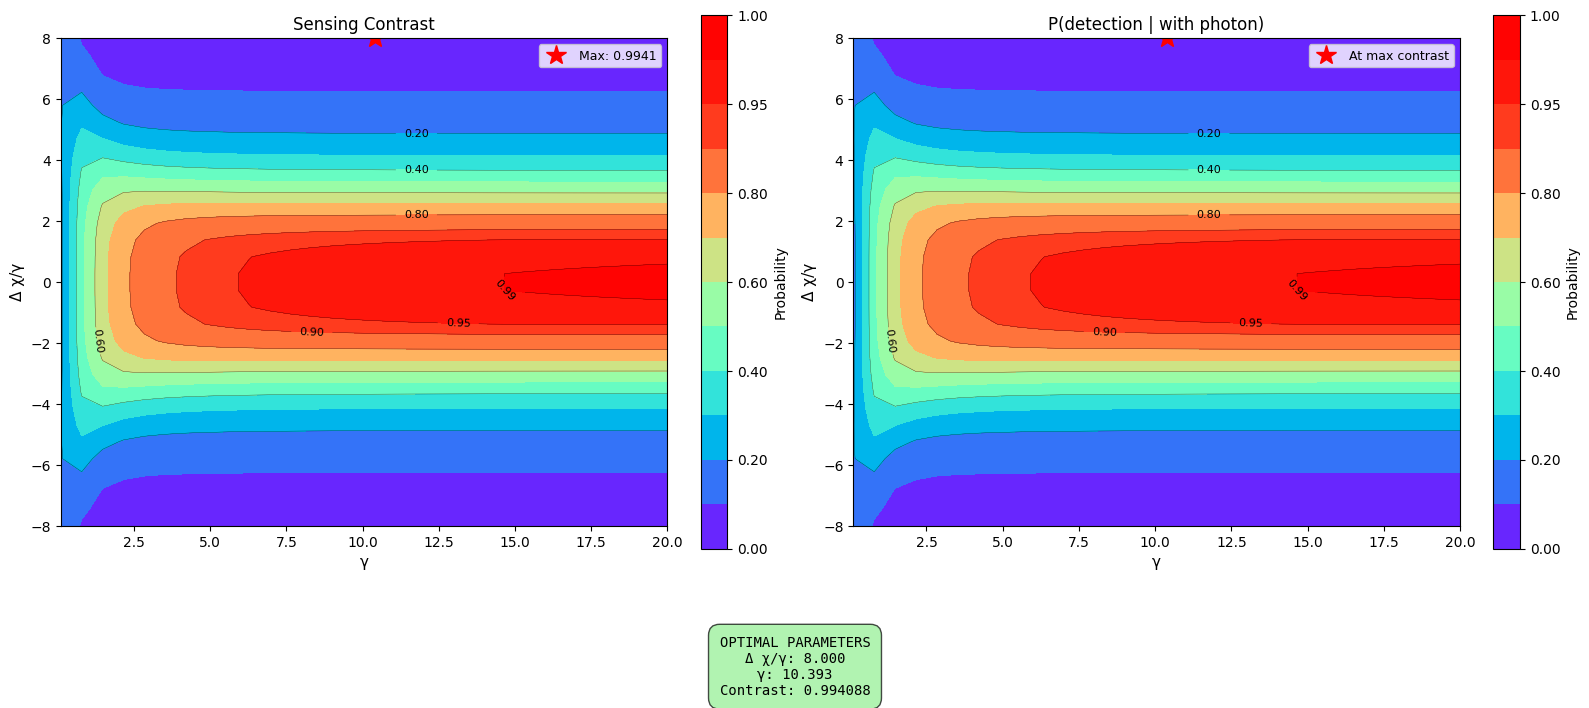

In [37]:
# Plot asymmetry-gamma sweep results
# Compare with chi-gamma sweep to see how asymmetry affects optimal regions
plot_sweep_results(
    results_asymmetry_gamma,
    results_to_plot=['contrast_map', 'detection_map'],
    mark_optimal=True
)
plt.show()